In [1]:
import os
import sys
import warnings
import glob
import datetime
import numpy as np
import pandas as pd
import joblib
from sqlalchemy import text

warnings.filterwarnings('ignore')

BASE_DIR    = os.path.expanduser("~/sentinelmesh")
MODELS_DIR  = os.path.join(BASE_DIR, "models")
DATA_DIR    = os.path.join(BASE_DIR, "data")
CSV_PATH    = os.path.join(DATA_DIR, "processed", "phase1_ml_ready.csv")
TON_PATH    = os.path.join(DATA_DIR, "TON_IoT/Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv")

sys.path.insert(0, BASE_DIR)
from etl.utils.db_connect import get_engine
engine = get_engine()

CHAMPION_MODEL = "XGBoost"
MODEL_VERSION  = "1.0"

print("✅ Config loaded")
print(f"   Models dir : {MODELS_DIR}")
print(f"   CSV path   : {CSV_PATH}")
print(f"   Champion   : {CHAMPION_MODEL} v{MODEL_VERSION}")

✅ Config loaded
   Models dir : /Users/ebimol/sentinelmesh/models
   CSV path   : /Users/ebimol/sentinelmesh/data/processed/phase1_ml_ready.csv
   Champion   : XGBoost v1.0


In [2]:
model_files = {
    "RandomForest" : os.path.join(MODELS_DIR, "rf_v1.pkl"),
    "XGBoost"      : os.path.join(MODELS_DIR, "xgb_v1.pkl"),
    "LightGBM"     : os.path.join(MODELS_DIR, "lgb_v1.pkl"),
}

models = {}
for name, path in model_files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ Model not found: {path}\n"
            f"   Run notebook 02_model_training.ipynb first."
        )
    models[name] = joblib.load(path)
    print(f"✅ Loaded {name:15s}  ← {path}")

rf_model  = models["RandomForest"]
xgb_model = models["XGBoost"]
lgb_model = models["LightGBM"]

✅ Loaded RandomForest     ← /Users/ebimol/sentinelmesh/models/rf_v1.pkl
✅ Loaded XGBoost          ← /Users/ebimol/sentinelmesh/models/xgb_v1.pkl
✅ Loaded LightGBM         ← /Users/ebimol/sentinelmesh/models/lgb_v1.pkl


In [3]:
FEATURE_COLS = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
    'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC',
    'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT',
    'Number', 'Variance',
]

print("Loading stg_harmonized from PostgreSQL…")
with engine.connect() as con:
    df_stg = pd.read_sql("""
        SELECT id AS stg_id,
               dataset_source,
               unified_label,
               attack_family,
               is_attack,
               protocol,
               src_bytes,
               dst_bytes,
               total_bytes,
               total_pkts,
               duration
        FROM stg_harmonized
        ORDER BY id
    """, con)

print(f"✅ stg_harmonized rows loaded : {len(df_stg):,}")
print(f"   CICIoT2023 rows : {(df_stg['dataset_source']=='CICIoT2023').sum():,}")
print(f"   TON_IoT rows    : {(df_stg['dataset_source']=='TON_IoT').sum():,}")

print("\nLoading phase1_ml_ready.csv for feature extraction…")
df_cic = pd.read_csv(CSV_PATH, low_memory=False)

df_cic[FEATURE_COLS] = (
    df_cic[FEATURE_COLS]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(df_cic[FEATURE_COLS].median(numeric_only=True))
)

print(f"✅ CICIoT feature matrix : {df_cic[FEATURE_COLS].shape}")

n_ton = (df_stg['dataset_source'] == 'TON_IoT').sum()

df_cic_source = pd.read_csv(CSV_PATH)
cic_medians = df_cic_source[FEATURE_COLS].median()

df_ton_raw = pd.read_csv(TON_PATH, low_memory=False)
df_ton_features = pd.DataFrame(
    np.tile(cic_medians.values, (len(df_ton_raw), 1)),
    columns=FEATURE_COLS
)

# Overwrite with real TON values for overlapping semantics
overlap = {
    'src_bytes' : 'Tot size',   # TON src_bytes  → CIC Tot size
    'dst_bytes' : 'Tot sum',    # TON dst_bytes  → CIC Tot sum
    'src_pkts'  : 'Number',     # TON src_pkts   → CIC Number
    'dst_pkts'  : 'Min',        # TON dst_pkts   → CIC Min
    'duration'  : 'IAT',        # TON duration   → CIC IAT
}
for ton_col, cic_col in overlap.items():
    if cic_col in FEATURE_COLS:
        df_ton_features[cic_col] = pd.to_numeric(
            df_ton_raw[ton_col], errors='coerce'
        ).fillna(cic_medians[cic_col]).values
        

print(f"TON_IoT feature matrix (median-imputed): {df_ton_features.shape}")


X_all = pd.concat(
    [df_cic[FEATURE_COLS], df_ton_features],
    ignore_index=True
)

n_stg = len(df_stg)
if len(X_all) > n_stg:
    X_all = X_all.iloc[:n_stg]
elif len(X_all) < n_stg:
    pad = pd.DataFrame(
        np.zeros((n_stg - len(X_all), len(FEATURE_COLS))),
        columns=FEATURE_COLS
    )
    X_all = pd.concat([X_all, pad], ignore_index=True)

print(f"\n✅ Combined feature matrix : {X_all.shape}")
print(f"   Aligned with stg rows  : {n_stg:,}")

Loading stg_harmonized from PostgreSQL…
✅ stg_harmonized rows loaded : 452,570
   CICIoT2023 rows : 241,527
   TON_IoT rows    : 211,043

Loading phase1_ml_ready.csv for feature extraction…
✅ CICIoT feature matrix : (241527, 39)
TON_IoT feature matrix (median-imputed): (211043, 39)

✅ Combined feature matrix : (452570, 39)
   Aligned with stg rows  : 452,570


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Running inference with all three models…\n")

scored_at = datetime.datetime.now()

def score_model(model, model_name, version, X, df_meta, scored_at):
    preds  = model.predict(X)
    probas = model.predict_proba(X)[:, 1]

    df_p = pd.DataFrame({
        "stg_id"          : df_meta["stg_id"].values,
        "dataset_source"  : df_meta["dataset_source"].values,
        "model_name"      : model_name,
        "model_version"   : version,
        "predicted_label" : preds.astype(int),
        "predicted_prob"  : np.round(probas, 4),
        "anomaly_score"   : np.round(probas, 4),
        "ground_truth"    : df_meta["is_attack"].astype(int).values,
        "attack_family"   : df_meta["attack_family"].values,
        "unified_label"   : df_meta["unified_label"].values,
        "scored_at"       : scored_at,
    })

    df_p["correct"] = (df_p["predicted_label"] == df_p["ground_truth"])
    
    acc = df_p["correct"].mean()
    overall_f1   = f1_score(df_p["ground_truth"], df_p["predicted_label"], average="weighted", zero_division=0)
    overall_prec = precision_score(df_p["ground_truth"], df_p["predicted_label"], average="weighted", zero_division=0)
    overall_rec  = recall_score(df_p["ground_truth"], df_p["predicted_label"], average="weighted", zero_division=0)
    print(f"  {model_name:15s}  acc={acc:.4f}  f1={overall_f1:.4f}  rows={len(df_p):,}")
    
    for src in ["CICIoT2023", "TON_IoT"]:
        mask = df_p["dataset_source"] == src
        if mask.sum() == 0:
            continue
        src_f1 = f1_score(df_p.loc[mask, "ground_truth"], df_p.loc[mask, "predicted_label"], average="weighted", zero_division=0)
        print(f"    └─ [{src}]  F1={src_f1:.4f}  n={mask.sum():,}")
    
    return df_p

results = {}
for name, model in models.items():
    results[name] = score_model(
        model, name, MODEL_VERSION, X_all, df_stg, scored_at
    )

df_predictions = pd.concat(list(results.values()), ignore_index=True)
print(f"\n✅ Total prediction rows   : {len(df_predictions):,}")
print(f"   Models scored          : {df_predictions['model_name'].nunique()}")
print(f"   Unique stg_ids covered : {df_predictions['stg_id'].nunique():,}")

Running inference with all three models…

  RandomForest     acc=0.8656  f1=0.8392  rows=452,570
    └─ [CICIoT2023]  F1=0.9580  n=241,527
    └─ [TON_IoT]  F1=0.6605  n=211,043
  XGBoost          acc=0.8643  f1=0.8293  rows=452,570
    └─ [CICIoT2023]  F1=0.9520  n=241,527
    └─ [TON_IoT]  F1=0.6605  n=211,043
  LightGBM         acc=0.8617  f1=0.8258  rows=452,570
    └─ [CICIoT2023]  F1=0.9469  n=241,527
    └─ [TON_IoT]  F1=0.6605  n=211,043

✅ Total prediction rows   : 1,357,710
   Models scored          : 3
   Unique stg_ids covered : 452,570


In [5]:
APPEND_MODE = False   # change to True to accumulate runs

WRITE_COLS = [
    "stg_id", "dataset_source", "model_name", "model_version",
    "predicted_label", "predicted_prob", "anomaly_score",
    "ground_truth", "attack_family", "unified_label", "correct", "scored_at",
]

with engine.connect() as con:
    if not APPEND_MODE:
        con.execute(text("TRUNCATE TABLE ml_prediction_log RESTART IDENTITY"))
        con.commit()
        print("🗑  Existing predictions cleared (TRUNCATE)")

CHUNK_SIZE = 2000
total      = len(df_predictions)
written    = 0

for i in range(0, total, CHUNK_SIZE):
    chunk = df_predictions[WRITE_COLS].iloc[i : i + CHUNK_SIZE]
    chunk.to_sql(
        "ml_prediction_log", engine,
        if_exists="append", index=False,
        method="multi", chunksize=CHUNK_SIZE,
    )
    written += len(chunk)
    pct = written / total * 100
    print(f"   Written {written:,} / {total:,}  ({pct:.1f}%)", end="\r")

print(f"\n✅ ml_prediction_log — {written:,} rows written")

🗑  Existing predictions cleared (TRUNCATE)
   Written 1,357,710 / 1,357,710  (100.0%)
✅ ml_prediction_log — 1,357,710 rows written


In [6]:
import datetime

df_champ = results[CHAMPION_MODEL].copy()

N_DEVICES = 50
N_DAYS    = 90
end_date  = datetime.date(2026, 6, 11)
date_range = [
    (end_date - datetime.timedelta(days=N_DAYS - 1 - i))
    for i in range(N_DAYS)
]

df_champ = df_champ.reset_index(drop=True)
df_champ["device_id"] = [
    "DEV_" + str((i % N_DEVICES) + 1).zfill(3)
    for i in range(len(df_champ))
]
df_champ["risk_date"] = [
    date_range[(i // N_DEVICES) % N_DAYS]
    for i in range(len(df_champ))
]

grp = df_champ.groupby(["device_id", "risk_date", "dataset_source"])

agg = grp.agg(
    total_flows   = ("predicted_label", "count"),
    attack_flows  = ("predicted_label", "sum"),
    total_bytes   = ("stg_id",  "count"),
    total_pkts    = ("stg_id",  "count"),
    avg_duration  = ("anomaly_score", "mean"),
).reset_index()

agg["benign_flows"] = agg["total_flows"] - agg["attack_flows"]
agg["attack_ratio"] = agg["attack_flows"] / agg["total_flows"]

top_fam = (
    df_champ[df_champ["predicted_label"] == 1]
    .groupby(["device_id", "risk_date", "dataset_source"])["attack_family"]
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else "None")
    .reset_index()
    .rename(columns={"attack_family": "top_attack_family"})
)
agg = agg.merge(top_fam, on=["device_id", "risk_date", "dataset_source"], how="left")
agg["top_attack_family"] = agg["top_attack_family"].fillna("None")

uniq_types = (
    df_champ[df_champ["predicted_label"] == 1]
    .groupby(["device_id", "risk_date", "dataset_source"])["unified_label"]
    .nunique()
    .reset_index()
    .rename(columns={"unified_label": "unique_attack_types"})
)
agg = agg.merge(uniq_types, on=["device_id", "risk_date", "dataset_source"], how="left")
agg["unique_attack_types"] = agg["unique_attack_types"].fillna(0).astype(int)

dom_proto = (
    df_stg.reset_index(drop=True)
    .assign(
        device_id = lambda d: ["DEV_" + str((i % N_DEVICES)+1).zfill(3) for i in range(len(d))],
        risk_date = lambda d: [date_range[(i // N_DEVICES) % N_DAYS] for i in range(len(d))]
    )
    .groupby(["device_id", "risk_date", "dataset_source"])["protocol"]
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else "TCP")
    .reset_index()
    .rename(columns={"protocol": "dominant_protocol"})
)
agg = agg.merge(dom_proto, on=["device_id", "risk_date", "dataset_source"], how="left")
agg["dominant_protocol"] = agg["dominant_protocol"].fillna("TCP")

agg["risk_score"] = (
    0.60 * agg["attack_ratio"] +
    0.25 * (agg["unique_attack_types"] / 10).clip(0, 1) +
    0.15 * agg["attack_ratio"]
).clip(0, 1) * 100

agg["risk_tier"] = pd.cut(
    agg["risk_score"],
    bins=[-0.1, 25, 50, 75, 100],
    labels=["Low", "Medium", "High", "Critical"]
).astype(str)

agg["ingest_timestamp"] = datetime.datetime.now()

print(f"✅ Aggregated {len(agg):,} device-day records")
print(agg["risk_tier"].value_counts().to_string())

with engine.connect() as con:
    con.execute(text("TRUNCATE TABLE fact_device_risk_daily RESTART IDENTITY"))
    con.commit()

WRITE_RISK_COLS = [
    "device_id", "risk_date", "dataset_source", "total_flows", "attack_flows",
    "benign_flows", "attack_ratio", "top_attack_family", "unique_attack_types",
    "dominant_protocol", "risk_score", "risk_tier", "ingest_timestamp",
]

agg[WRITE_RISK_COLS].to_sql(
    "fact_device_risk_daily", engine,
    if_exists="append", index=False,
    method="multi", chunksize=500,
)
print(f"✅ fact_device_risk_daily refreshed — {len(agg):,} records")

✅ Aggregated 9,000 device-day records
risk_tier
Critical    9000
✅ fact_device_risk_daily refreshed — 9,000 records


In [7]:
df_atk_pred = df_champ[df_champ["predicted_label"] == 1].copy()
df_atk_pred = df_atk_pred.reset_index(drop=True)
df_atk_pred["event_date"] = [date_range[i % N_DAYS] for i in range(len(df_atk_pred))]

df_stg_atk = df_stg[
    df_stg["stg_id"].isin(df_atk_pred["stg_id"])
][["stg_id", "total_bytes", "total_pkts", "duration"]].copy()

df_atk_pred = df_atk_pred.merge(df_stg_atk, on="stg_id", how="left")

agg_atk = df_atk_pred.groupby(
    ["event_date", "dataset_source", "attack_family", "unified_label"]
).agg(
    flow_count   = ("predicted_label", "count"),
    total_bytes  = ("total_bytes",     "sum"),
    total_pkts   = ("total_pkts",      "sum"),
    avg_duration = ("duration",        "mean"),
).reset_index()

agg_atk["ingest_timestamp"] = datetime.datetime.now()

df_proto_atk = (
    df_atk_pred
    .merge(df_stg[["stg_id", "protocol"]], on="stg_id", how="left")
    .groupby(["event_date", "dataset_source", "attack_family", "unified_label"])["protocol"]
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else "TCP")
    .reset_index()
    .rename(columns={"protocol": "protocol"})
)

agg_atk = agg_atk.merge(
    df_proto_atk,
    on=["event_date", "dataset_source", "attack_family", "unified_label"],
    how="left"
)
agg_atk["protocol"] = agg_atk["protocol"].fillna("TCP")

print(f"✅ fact_attack_timeline: {len(agg_atk):,} records")
print(f"   Date range  : {agg_atk['event_date'].min()} → {agg_atk['event_date'].max()}")
print(f"   Attack fams : {agg_atk['attack_family'].nunique()}")

with engine.connect() as con:
    con.execute(text("TRUNCATE TABLE fact_attack_timeline RESTART IDENTITY"))
    con.commit()

WRITE_ATK_COLS = [
    "event_date", "dataset_source", "attack_family", "unified_label",
    "protocol", "flow_count", "total_bytes", "total_pkts",
    "avg_duration", "ingest_timestamp",
]
agg_atk[WRITE_ATK_COLS].to_sql(
    "fact_attack_timeline", engine,
    if_exists="append", index=False,
    method="multi", chunksize=500,
)
print(f"✅ fact_attack_timeline refreshed — {len(agg_atk):,} records")

✅ fact_attack_timeline: 1,980 records
   Date range  : 2026-03-14 → 2026-06-11
   Attack fams : 9
✅ fact_attack_timeline refreshed — 1,980 records


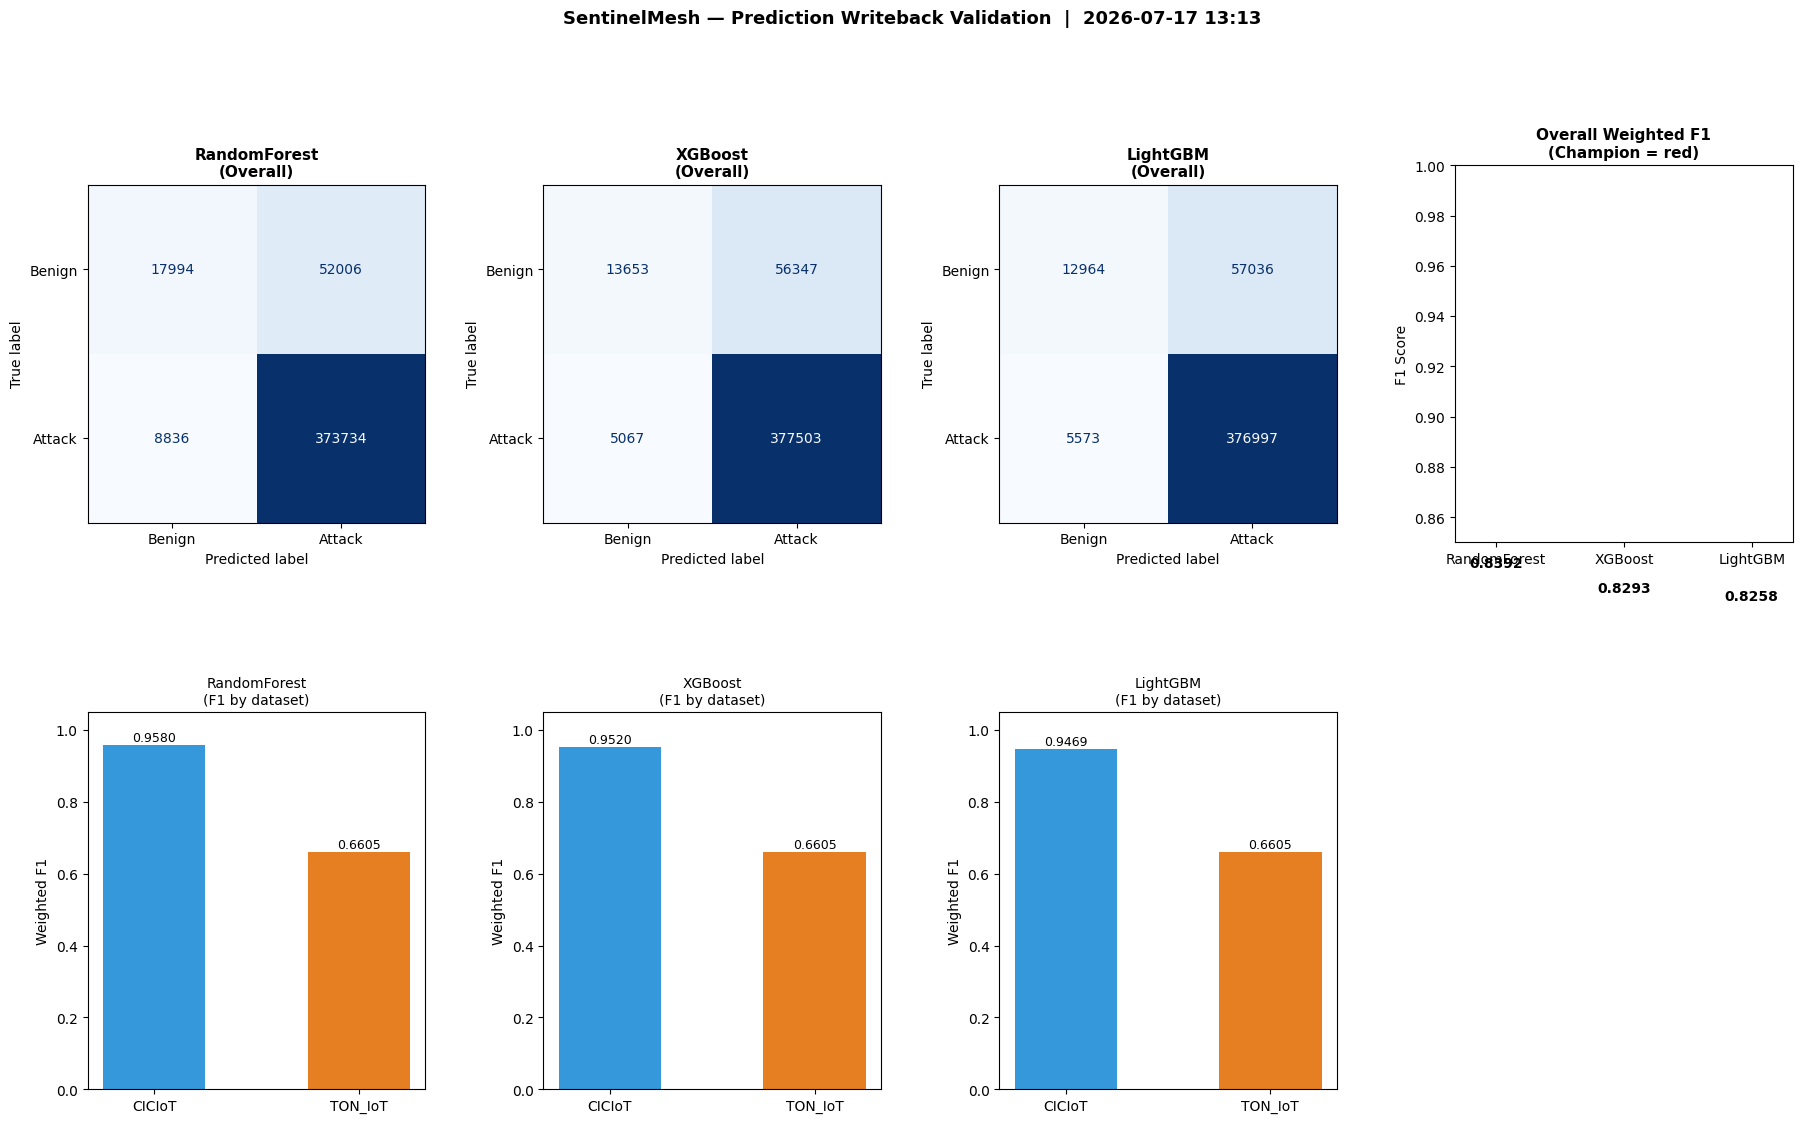

✅ Chart saved: phase1_prediction_writeback.png
✅ Summary CSV saved: /Users/ebimol/sentinelmesh/data/processed/prediction_summary.csv

  model_name model_version  scored_at  total_rows  weighted_f1  weighted_prec  weighted_rec  cic_f1  ton_f1  champion
RandomForest           1.0 2026-07-17      452570       0.8392         0.8458        0.8656  0.9580  0.6605     False
     XGBoost           1.0 2026-07-17      452570       0.8293         0.8483        0.8643  0.9520  0.6605      True
    LightGBM           1.0 2026-07-17      452570       0.8258         0.8424        0.8617  0.9469  0.6605     False


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, precision_score, recall_score
)

fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

summary_rows = []

for col_idx, (name, df_m) in enumerate(results.items()):
    cm   = confusion_matrix(df_m["ground_truth"], df_m["predicted_label"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Attack"])
    ax_cm = fig.add_subplot(gs[0, col_idx])
    disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
    ax_cm.set_title(f"{name}\n(Overall)", fontsize=11, fontweight="bold")

    ax_ds = fig.add_subplot(gs[1, col_idx])
    ds_f1 = []
    for src in ["CICIoT2023", "TON_IoT"]:
        mask = df_m["dataset_source"] == src
        if mask.sum() == 0:
            ds_f1.append(0.0)
            continue
        f = f1_score(
            df_m.loc[mask, "ground_truth"],
            df_m.loc[mask, "predicted_label"],
            average="weighted", zero_division=0
        )
        ds_f1.append(f)
    bars = ax_ds.bar(["CICIoT", "TON_IoT"], ds_f1,
                     color=["#3498db", "#e67e22"], width=0.5)
    ax_ds.set_ylim(0, 1.05)
    ax_ds.set_title(f"{name}\n(F1 by dataset)", fontsize=10)
    ax_ds.set_ylabel("Weighted F1")
    for bar, val in zip(bars, ds_f1):
        ax_ds.text(bar.get_x() + bar.get_width()/2,
                   val + 0.01, f"{val:.4f}", ha="center", fontsize=9)

    overall_f1 = f1_score(
        df_m["ground_truth"], df_m["predicted_label"],
        average="weighted", zero_division=0
    )
    overall_prec = precision_score(
        df_m["ground_truth"], df_m["predicted_label"],
        average="weighted", zero_division=0
    )
    overall_rec = recall_score(
        df_m["ground_truth"], df_m["predicted_label"],
        average="weighted", zero_division=0
    )
    summary_rows.append({
        "model_name"      : name,
        "model_version"   : MODEL_VERSION,
        "scored_at"       : scored_at.date(),
        "total_rows"      : len(df_m),
        "weighted_f1"     : round(overall_f1, 4),
        "weighted_prec"   : round(overall_prec, 4),
        "weighted_rec"    : round(overall_rec, 4),
        "cic_f1"          : round(ds_f1[0], 4),
        "ton_f1"          : round(ds_f1[1], 4),
        "champion"        : name == CHAMPION_MODEL,
    })

ax_f1 = fig.add_subplot(gs[0, 3])
names  = [r["model_name"] for r in summary_rows]
f1s    = [r["weighted_f1"] for r in summary_rows]
colors = ["#e74c3c" if n == CHAMPION_MODEL else "#95a5a6" for n in names]
bars   = ax_f1.bar(names, f1s, color=colors, width=0.4)
ax_f1.set_ylim(0.85, 1.0)
ax_f1.set_title("Overall Weighted F1\n(Champion = red)", fontsize=11, fontweight="bold")
ax_f1.set_ylabel("F1 Score")
for bar, val in zip(bars, f1s):
    ax_f1.text(bar.get_x() + bar.get_width()/2,
               val + 0.001, f"{val:.4f}", ha="center", fontweight="bold")

fig.add_subplot(gs[1, 3]).set_visible(False)

plt.suptitle(
    f"SentinelMesh — Prediction Writeback Validation  |  {scored_at.strftime('%Y-%m-%d %H:%M')}",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig("phase1_prediction_writeback.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: phase1_prediction_writeback.png")

df_summary = pd.DataFrame(summary_rows)
SUMMARY_PATH = os.path.join(BASE_DIR, "data", "processed", "prediction_summary.csv")
df_summary.to_csv(SUMMARY_PATH, index=False)
print(f"✅ Summary CSV saved: {SUMMARY_PATH}")
print(f"\n{df_summary.to_string(index=False)}")

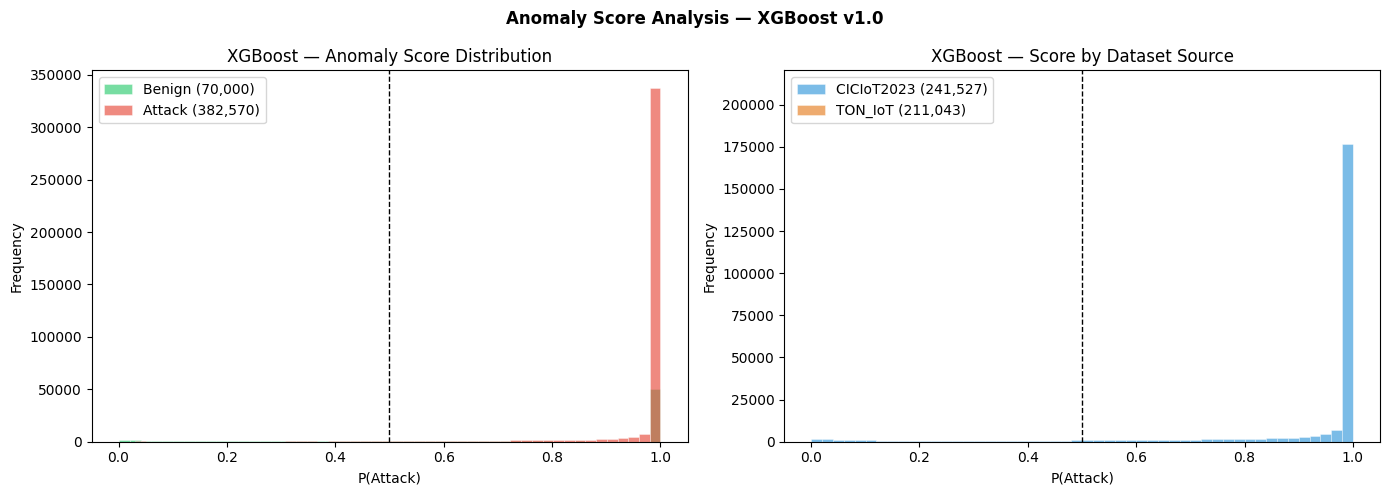

✅ Anomaly distribution chart saved.


In [9]:
df_xgb = results[CHAMPION_MODEL]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, lname in [(0, "#2ecc71", "Benign"), (1, "#e74c3c", "Attack")]:
    mask = df_xgb["ground_truth"] == label
    axes[0].hist(
        df_xgb.loc[mask, "anomaly_score"],
        bins=50, alpha=0.65,
        color=color, label=f"{lname} ({mask.sum():,})",
        edgecolor="white", linewidth=0.4
    )
axes[0].set_title(f"{CHAMPION_MODEL} — Anomaly Score Distribution")
axes[0].set_xlabel("P(Attack)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1, label="threshold=0.5")

for src, color in [("CICIoT2023", "#3498db"), ("TON_IoT", "#e67e22")]:
    mask = df_xgb["dataset_source"] == src
    axes[1].hist(
        df_xgb.loc[mask, "anomaly_score"],
        bins=50, alpha=0.65,
        color=color, label=f"{src} ({mask.sum():,})",
        edgecolor="white", linewidth=0.4
    )
axes[1].set_title(f"{CHAMPION_MODEL} — Score by Dataset Source")
axes[1].set_xlabel("P(Attack)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)

plt.suptitle(f"Anomaly Score Analysis — {CHAMPION_MODEL} v{MODEL_VERSION}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase1_anomaly_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Anomaly distribution chart saved.")

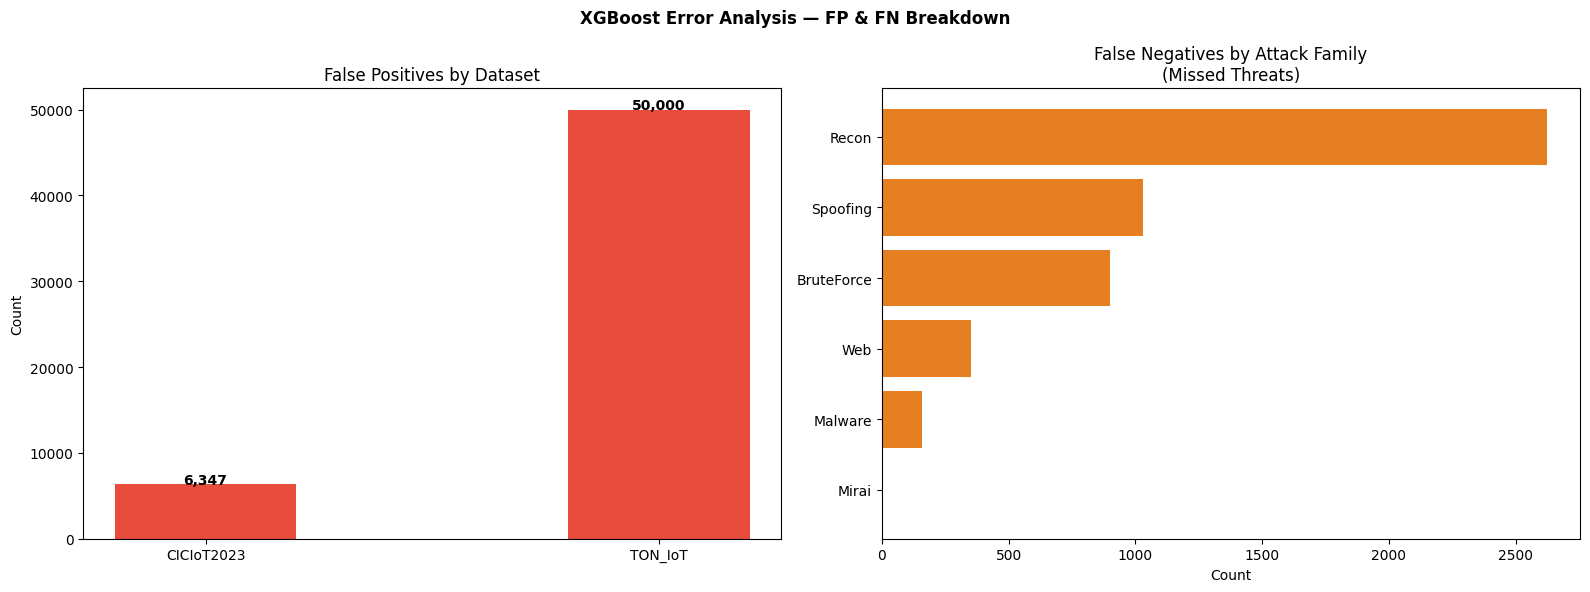

✅ Error analysis chart saved.
   Total FP  : 56,347  (12.45%)
   Total FN  : 5,067  (1.12%)
   Correct   : 391,156  (86.43%)


In [10]:
df_xgb = results[CHAMPION_MODEL].copy()
df_xgb["error_type"] = "Correct"
df_xgb.loc[(df_xgb["predicted_label"] == 1) & (df_xgb["ground_truth"] == 0), "error_type"] = "FP"
df_xgb.loc[(df_xgb["predicted_label"] == 0) & (df_xgb["ground_truth"] == 1), "error_type"] = "FN"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fp_ds = (
    df_xgb[df_xgb["error_type"] == "FP"]
    .groupby("dataset_source").size().reset_index(name="count")
)
axes[0].bar(fp_ds["dataset_source"], fp_ds["count"], color="#e74c3c", width=0.4)
axes[0].set_title("False Positives by Dataset")
axes[0].set_ylabel("Count")
for i, row in fp_ds.iterrows():
    axes[0].text(i, row["count"] + 20, f'{row["count"]:,}', ha="center", fontweight="bold")

fn_fam = (
    df_xgb[df_xgb["error_type"] == "FN"]
    .groupby("attack_family").size()
    .sort_values(ascending=True)
    .reset_index(name="count")
)
axes[1].barh(fn_fam["attack_family"], fn_fam["count"], color="#e67e22")
axes[1].set_title("False Negatives by Attack Family\n(Missed Threats)")
axes[1].set_xlabel("Count")

plt.suptitle(f"{CHAMPION_MODEL} Error Analysis — FP & FN Breakdown",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase1_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

total_fp = (df_xgb["error_type"] == "FP").sum()
total_fn = (df_xgb["error_type"] == "FN").sum()
total    = len(df_xgb)
print(f"✅ Error analysis chart saved.")
print(f"   Total FP  : {total_fp:,}  ({total_fp/total:.2%})")
print(f"   Total FN  : {total_fn:,}  ({total_fn/total:.2%})")
print(f"   Correct   : {total-total_fp-total_fn:,}  ({(total-total_fp-total_fn)/total:.2%})")

In [11]:
CHECKS = {
    "ml_prediction_log"     : """
        SELECT model_name, COUNT(*) AS rows,
               ROUND(AVG(predicted_prob)::numeric, 4) AS avg_prob,
               SUM(CASE WHEN correct THEN 1 ELSE 0 END) AS correct_count
        FROM ml_prediction_log GROUP BY model_name ORDER BY model_name""",

    "fact_device_risk_daily": """
        SELECT risk_tier, COUNT(*) AS records,
               ROUND(AVG(risk_score)::numeric, 2) AS avg_score
        FROM fact_device_risk_daily GROUP BY risk_tier ORDER BY avg_score DESC""",

    "fact_attack_timeline"  : """
        SELECT attack_family, COUNT(*) AS records, SUM(flow_count) AS total_flows
        FROM fact_attack_timeline GROUP BY attack_family ORDER BY total_flows DESC""",

    "stg_harmonized"        : """
        SELECT dataset_source, COUNT(*) AS rows
        FROM stg_harmonized GROUP BY dataset_source""",
}

print("=" * 65)
print("  FINAL VALIDATION — SentinelMesh Database State")
print("=" * 65)

with engine.connect() as con:
    for table, query in CHECKS.items():
        result = con.execute(text(query)).fetchall()
        df_v   = pd.DataFrame(result)
        print(f"\n📋 {table}")
        print(df_v.to_string(index=False))

print("\n" + "=" * 65)
print(f"  Writeback complete  |  scored_at: {scored_at}")
print(f"  Champion model     : {CHAMPION_MODEL} v{MODEL_VERSION}")
print("=" * 65)

  FINAL VALIDATION — SentinelMesh Database State

📋 ml_prediction_log
  model_name   rows avg_prob  correct_count
    LightGBM 452570   0.9476         389961
RandomForest 452570   0.9162         391728
     XGBoost 452570   0.9486         391156

📋 fact_device_risk_daily
risk_tier  records avg_score
 Critical     9000     93.63

📋 fact_attack_timeline
attack_family  records  total_flows
         DDoS      360        80000
          DoS      270        60000
        Recon      270        57377
       Benign      180        56347
          Web      180        44892
      Malware      180        43060
     Spoofing      270        40013
   BruteForce      180        32162
        Mirai       90        19999

📋 stg_harmonized
dataset_source   rows
    CICIoT2023 241527
       TON_IoT 211043

  Writeback complete  |  scored_at: 2026-07-17 13:13:11.294584
  Champion model     : XGBoost v1.0


In [12]:
df_summary.rename(columns={"champion": "is_champion"}).to_sql(
    "ml_model_registry", engine,
    if_exists="append", index=False,
    method="multi",
)
print("✅ ml_model_registry populated")

with engine.connect() as con:
    rows = con.execute(text(
        "SELECT model_name, weighted_f1, is_champion "
        "FROM ml_model_registry ORDER BY weighted_f1 DESC"
    )).fetchall()
    df_reg = pd.DataFrame(rows, columns=["model_name", "weighted_f1", "is_champion"])
    print(df_reg.to_string(index=False))

print("\n✅ 04_prediction_writeback — all cells complete.")
print("   Refresh your Streamlit dashboard at http://localhost:8501")
print("   Refresh your Metabase dashboard at http://localhost:3000/dashboard/2-iot-attack-command-centre")

✅ ml_model_registry populated
  model_name weighted_f1  is_champion
RandomForest      0.8392        False
RandomForest      0.8392        False
RandomForest      0.8392        False
     XGBoost      0.8293         True
     XGBoost      0.8293         True
     XGBoost      0.8293         True
    LightGBM      0.8258        False
    LightGBM      0.8258        False
    LightGBM      0.8258        False

✅ 04_prediction_writeback — all cells complete.
   Refresh your Streamlit dashboard at http://localhost:8501
   Refresh your Metabase dashboard at http://localhost:3000/dashboard/2-iot-attack-command-centre
